In [67]:
import operator
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Any, Annotated, Dict, Literal
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from pydantic import BaseModel, Field

In [68]:
load_dotenv()
model = ChatGroq(model="llama-3.3-70b-versatile", 
                 api_key=os.getenv("API_KEY"),
                 temperature=0.1)

In [69]:
class SentimentSchema(BaseModel):
    sentiment: Literal["Positive","Negative"] = Field(description="evaluate the sentiment of comment")

In [70]:
class diagnosisSchema(BaseModel):
    issue_type:Literal["ux","camera","storage"] =Field(description="provide the type of issue based on review")
    tone: Literal["angry","disappointed","calm","frustrated"] = Field(description="evaluate the tone of comment")
    urgency: Literal["low","medium","high"] = Field(description="evaluate how quickly it need to be addressed")

In [71]:
structured_output=model.with_structured_output(SentimentSchema)
diagnosis_structured_output=model.with_structured_output(diagnosisSchema)


In [72]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["Positive","Negative"]
    diagnosis: dict
    response: str
    

In [73]:
def find_sentiment(state: ReviewState):
    prompt=f"evaluate the sentiment of this review ,\n {state['review']}"

    sentiment=structured_output.invoke(prompt).sentiment
    return {"sentiment":sentiment}

In [74]:
def positive_response(state: ReviewState):
    prompt=f"Thank the user cordially for the positive review for the review:\n {state['review']}"
    
    response=model.invoke(prompt).content
    
    return {"response": response}

In [81]:
def run_diagnosis(state: ReviewState):
    prompt =f"analyse the review: \n {state['review']} and run_diagnosis and return issue_type,tone,urgency"
    diagnosis=diagnosis_structured_output.invoke(prompt)
    return {"diagnosis":diagnosis.model_dump()}

In [82]:
def negative_response(state:ReviewState):
    prompt =f"Respond to customer with empathy for the review:\n {state['review']} and also considering diagnosis: \n {state['diagnosis']}"
    
    response=model.invoke(prompt).content
    return {"response":response}

In [83]:
def sentiment_condition(state:ReviewState):
    if state['sentiment'] =="Positive":
        return "positive"
    else:
        return "negative"

In [84]:
graph=StateGraph(ReviewState)
graph.add_node("find_sentiment",find_sentiment)
graph.add_node("positive_response",positive_response)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("negative_response",negative_response)

graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",sentiment_condition,{
    "positive": "positive_response",
    "negative":"run_diagnosis"
})
graph.add_edge("run_diagnosis","negative_response")
graph.add_edge("negative_response",END)
graph.add_edge("positive_response",END)


workflow=graph.compile()

initial_state={
    "review": "the phone features are really disappointed, camera is low quality, still it is ok for the price range"
}

agent=workflow.invoke(initial_state)


In [85]:
agent

{'review': 'the phone features are really disappointed, camera is low quality, still it is ok for the price range',
 'sentiment': 'Negative',
 'diagnosis': {'issue_type': 'camera',
  'tone': 'disappointed',
  'urgency': 'low'},
 'response': "Dear valued customer,\n\nI'm so sorry to hear that the phone's features, particularly the camera, didn't quite meet your expectations. I can understand how disappointing it must be to experience low-quality camera performance. \n\nHowever, I appreciate your fairness in considering the price range and acknowledging that it's still an okay device. We strive to provide the best possible products at affordable prices, and it's great that you're taking that into account.\n\nRegarding the camera issue, I'd like to assure you that we're constantly working to improve our products and services. If you're experiencing any other problems or have suggestions for improvement, please don't hesitate to reach out to us. We're here to listen and help in any way we 

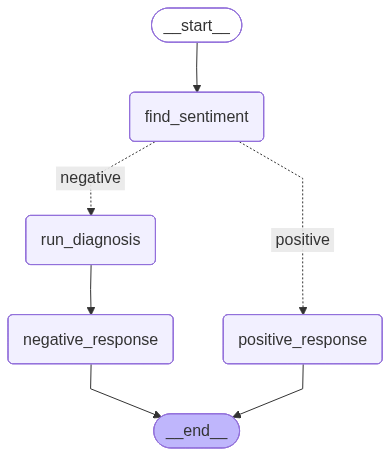

In [80]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())